In [4]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import OpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI

In [5]:
load_dotenv()

True

In [6]:
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
model=ChatOpenAI(api_key=api_key,model="gpt-4o-mini")

In [7]:
#state
class BLOGState(TypedDict):
    title: str
    outline: str
    content: str

In [8]:
def create_outline(state:BLOGState)->BLOGState:
    title=state["title"]
    query=f"give a detail outline in this {title}"
    outline=model.invoke(query).content
    state['outline']=outline
    return state





In [9]:
def create_blog(state):
    outline=state["outline"]
    topic=state["title"]
    query=f"give a vlog on this {outline}and topic {topic}"
    content=model.invoke(query).content
    state["content"]=content
    return state


In [10]:
graph=StateGraph(BLOGState)

#add nodes 
graph.add_node("create_outline",create_outline)
graph.add_node("create_blog",create_blog)

#add edges
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog",END)

#compile
workflow=graph.compile()

In [11]:
type(workflow)

langgraph.graph.state.CompiledStateGraph

In [12]:
initial_state={"title":"Rise of AI in India"}

In [14]:
result=workflow.invoke(initial_state)

In [15]:
print(result)

{'title': 'Rise of AI in India', 'outline': 'Certainly! Here’s a detailed outline for a discussion on the "Rise of AI in India." This outline can serve as a framework for a presentation, report, or paper on the topic.\n\n---\n\n**Title: The Rise of AI in India**\n\n**I. Introduction**\n   A. Definition of Artificial Intelligence (AI)\n   B. Brief historical context of AI development globally\n   C. The significance of AI in modern economies\n   D. Overview of India’s position in the global AI landscape\n\n**II. The Current State of AI in India**\n   A. Government initiatives and policies\n      1. National AI Strategy\n      2. Atal Innovation Mission\n      3. Digital India Initiative\n   B. Key sectors embracing AI\n      1. IT and Software Services\n      2. Healthcare\n      3. Agriculture\n      4. Finance and Banking\n      5. Manufacturing\n   C. Major AI startups and companies\n      1. Overview of leading AI startups (e.g., Niramai, SigTuple)\n      2. Established tech compani

In [17]:
result['outline']

'Certainly! Here’s a detailed outline for a discussion on the "Rise of AI in India." This outline can serve as a framework for a presentation, report, or paper on the topic.\n\n---\n\n**Title: The Rise of AI in India**\n\n**I. Introduction**\n   A. Definition of Artificial Intelligence (AI)\n   B. Brief historical context of AI development globally\n   C. The significance of AI in modern economies\n   D. Overview of India’s position in the global AI landscape\n\n**II. The Current State of AI in India**\n   A. Government initiatives and policies\n      1. National AI Strategy\n      2. Atal Innovation Mission\n      3. Digital India Initiative\n   B. Key sectors embracing AI\n      1. IT and Software Services\n      2. Healthcare\n      3. Agriculture\n      4. Finance and Banking\n      5. Manufacturing\n   C. Major AI startups and companies\n      1. Overview of leading AI startups (e.g., Niramai, SigTuple)\n      2. Established tech companies contributing to AI (e.g., TCS, Infosys)\n

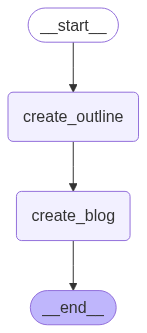

In [18]:
graph.compile()